<a href="https://colab.research.google.com/github/AhmadSyahreza/Katanya-kami-lomba/blob/main/Awal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Katanya Kami Lomba

Notebook ini digunakan untuk coding dan analisis data.

In [ ]:
!pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train1 = pd.read_csv('/content/drive/MyDrive/Lomba Data/train.csv')
test1 = pd.read_csv('/content/drive/MyDrive/Lomba Data/test.csv')
holidays = pd.read_csv('/content/drive/MyDrive/Lomba Data/holidays.csv')
movies = pd.read_csv('/content/drive/MyDrive/Lomba Data/movies.csv')
ticket_prices = pd.read_csv('/content/drive/MyDrive/Lomba Data/ticket_prices.csv')
test_history = pd.read_csv('/content/drive/MyDrive/Lomba Data/test_history.csv')
sample_submission = pd.read_csv('/content/drive/MyDrive/Lomba Data/sample_submission.csv')

In [ ]:
holidays

,date,day_tipe,holiday_tipe,holiday_name
0,2025-04-01,weekday,holiday,Idulfitri 1446 H
1,2025-04-02,weekday,normal,NaN
2,2025-04-03,weekday,normal,NaN
3,2025-04-04,friday,normal,NaN
4,2025-04-05,weekend,normal,NaN
...,...,...,...,...
361,2026-03-28,weekend,normal,NaN
362,2026-03-29,weekend,normal,NaN
363,2026-03-30,weekday,normal,NaN
364,2026-03-31,weekday,normal,NaN


In [ ]:
movies

,original_title,age_rating,genre,producer,director,writer,casts
0,120 BAHADUR,Remaja,"Action, War","Farhan Akhtar, Amit Chandrra, Ritesh Sidhwani",Razneesh Ghai,Sumit Arora,"Ankit Siwach, Farhan Akhtar, Amitabh Bachchan,..."
1,"13 DAYS, 13 NIGHTS",Remaja,"Action, War","Dimitri Rassam, Ardavan Safaee",Martin Bourboulon,"Martin Bourboulon, Alexandre Smia, Mohamed Bid...","Roschdy Zem, Lyna Khoudri, Sidse Babett Knudse..."
2,28 YEARS LATER,Dewasa,Thriller,"Danny Boyle, Alex Garland, Peter Rice",Danny Boyle,"Danny Boyle, Alex Garland","Jodie Comer, Aaron Taylor-Johnson, Jack O'Conn..."
3,28 YEARS LATER: THE BONE TEMPLE,Dewasa,Thriller,"Danny Boyle, Alex Garland, Andrew Macdonald",Nia DaCosta,Alex Garland,"Ralph Fiennes, Alfie Williams, Jack O'Connell,..."
4,5 CENTIMETERS PER SECOND (ANIMATION),Remaja,Animation,"Makoto Shinkai, Jin Ho Chung",Makoto Shinkai,Makoto Shinkai,"Kenji Mizuhashi, Yoshimi Kondou, Satomi Hanamu..."
...,...,...,...,...,...,...,...
392,WUTHERING HEIGHTS,Dewasa,"Romance, Drama","Emerald Fennell, Josey McNamara, Margot Robbie",Emerald Fennell,"Emerald Fennell, Emily Bronte","Margot Robbie, Jacob Elordi, Hong Chau, Shazad..."
393,YAKIN NIKAH,Remaja,"Drama, Romance","Shierly Kosasih, Ervina Isleyen",Pritagita Arianegara,"Bene Dion Rajagukguk, Sigit Sulistyo, Erwin Wu","Enzy Storia, Maxime Bouttier, Jourdy Pranata, ..."
394,YOU ARE THE APPLE OF MY EYE,Remaja,"Drama, Romance",Song Dae-chan,Cho Young-myoung,"Giddens Ko, Cho Young-myoung","Jung Jin-young, Kim Da-hyun, Demian, Kim Yo-ha..."
395,YOUR LETTER,Semua Umur,Animation,-,Kim Yong-hwan,Jeong Eun-kyeong,"Lee Suhyun, Kim Min-ju, Min Seung-woo, Nam Doh..."


In [ ]:
train1["date_show"] = pd.to_datetime(train1["date_show"])
test1["date_show"]  = pd.to_datetime(test1["date_show"])

print("Train shape : ", train1.shape)
print("Test shape : ", test1.shape)

Train shape :  (138959, 7)
Test shape :  (72611, 5)


In [ ]:
print("dari :", train1["date_show"].min() , " Sampai : " , train1["date_show"].max())
print("dari :", test1["date_show"].min() , " Sampai : " , test1["date_show"].max())

dari : 2025-10-04 00:00:00  Sampai :  2026-03-27 00:00:00
dari : 2025-10-04 00:00:00  Sampai :  2026-03-27 00:00:00


In [ ]:
print("Total Missing value : ", train1.isnull().sum())

Total Missing value :  date_show          66348
cinema_ids             0
city_name              0
movie_title            0
total_ticket           0
occupation_rate        0
total_show             0
dtype: int64


In [ ]:
print(train1[["total_ticket", "occupation_rate", "total_show"]].describe())

        total_ticket  occupation_rate     total_show
count  138959.000000    138959.000000  138959.000000
mean      354.122072        28.331061       7.730921
std       725.927987        22.618841      11.005488
min         1.000000         0.000000       1.000000
25%        69.000000        12.360000       3.000000
50%       161.000000        21.840000       5.000000
75%       361.000000        37.010000       8.000000
max     32845.000000       100.000000     285.000000


                 total_ticket  occupation_rate  total_show
total_ticket            1.000            0.309       0.786
occupation_rate         0.309            1.000       0.004
total_show              0.786            0.004       1.000


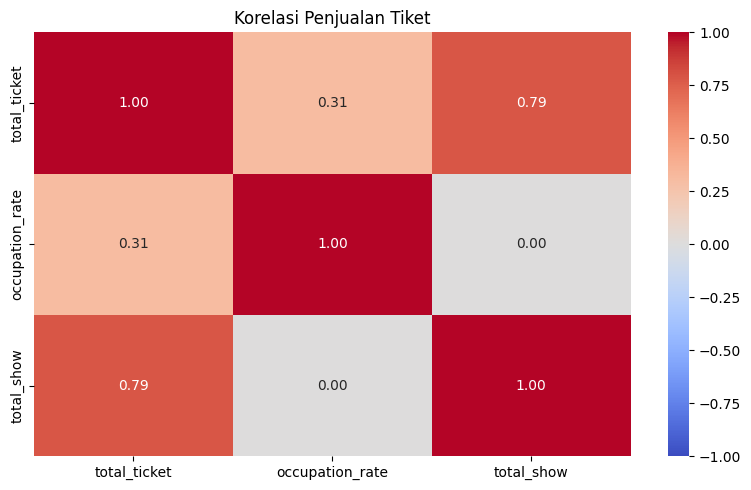

In [ ]:
num_cols = [
    "total_ticket",
    "occupation_rate",
    "total_show"
]

corr = train1[num_cols].corr(method="pearson")

print(corr.round(3))

plt.figure(figsize=(8, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Korelasi Penjualan Tiket")
plt.tight_layout()
plt.show()

In [ ]:
film_test = set(test1['movie_title'])
film_movies = set(movies['original_title'])
film_missing = film_test - film_movies
kota_test = set(test1['city_name'])
kota_prices = set(ticket_prices['city_name'])
kota_missing = kota_test - kota_prices

summary_data = {
    "Kategori Pengecekan": ["Judul Film", "Nama Kota"],
    "Total Unik": [len(film_test), len(kota_test)],
    "Ada": [len(film_test - film_missing), len(kota_test - kota_missing)],
    "Missing": [len(film_missing), len(kota_missing)],
    "Status": [
        " film belum terdaftar" if len(film_missing) > 0 else "",
        " kota belum terdaftar" if len(kota_missing) > 0 else ""
    ]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Kategori Pengecekan,Total Unik,Ada,Missing,Status
0,Judul Film,160,140,20,film belum terdaftar
1,Nama Kota,69,69,0,


In [ ]:
df_missing_movies = pd.DataFrame({
    "Judul Missing": sorted((film_missing))
})

display(df_missing_movies)

,Judul Missing
0,AVATAR: FIRE AND ASH (3D)
1,AVATAR: FIRE AND ASH (IMAX 3D)
2,BLADES OF THE GUARDIANS (IMAX 2D)
3,DANUR: THE LAST CHAPTER (IMAX 2D)
4,EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)
5,HOPPERS (3D)
6,HOPPERS (IMAX 2D)
7,MERCY (IMAX 2D)
8,PREDATOR: BADLANDS (3D)
9,PREDATOR: BADLANDS (IMAX 2D)


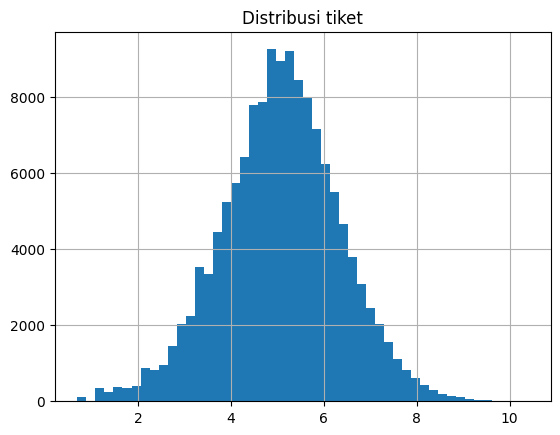

In [ ]:
np.log1p(train1['total_ticket']).hist(bins=50)
plt.title('Distribusi tiket')
plt.show()

In [ ]:
def find_d1(df):
    nat = df.groupby(['movie_title','date_show'])['total_ticket'].sum().reset_index()
    first = nat.groupby('movie_title')['date_show'].min()
    out = {}
    for m, g in nat.groupby('movie_title'):
        ds = set(g['date_show'])
        for d in sorted(ds):
            if {d + pd.Timedelta(days=1), d + pd.Timedelta(days=2)} <= ds:
                out[m] = d
                break
    f = pd.Series(out, name='D1').rename_axis('movie_title').reset_index()
    f['first_date'] = f['movie_title'].map(first)
    return f

f = find_d1(train1)
tmin, tmax = train1['date_show'].min(), train1['date_show'].max()
f = f[(f['D1'] > tmin + pd.Timedelta(days=2)) &
      (f['D1'] + pd.Timedelta(days=9) <= tmax) &
      ((f['D1'] - f['first_date']).dt.days <= 3)].reset_index(drop=True)

print("jumlah film :", len(f), "dari", train1['movie_title'].nunique())
f.head()

jumlah film : 108 dari 237


,movie_title,D1,first_date
0,28 YEARS LATER,2025-06-17,2025-06-17
1,A BIG BOLD BEAUTIFUL JOURNEY,2025-09-18,2025-09-18
2,A MINECRAFT MOVIE,2025-04-04,2025-04-04
3,A MINECRAFT MOVIE (3D),2025-04-09,2025-04-09
4,A MINECRAFT MOVIE (IMAX 2D),2025-04-08,2025-04-08


# **WINDOW**

Ini aku pakai window karena dari task paling utamanya diminta :
- data hari 1-3 terhadap minggu depannya
- berarti dalam 1 hari itu semua pertunjukan dan tiketnya seberapa ngaruh ke minggu depannya

In [ ]:
def build_windows(df): #DF nya dataset Train
windows = []

for (film, bioskop), group in df.groupby(['movie_title', 'cinema_ids']):
  group = group.sort_values('date_show').reset_index(drop=True)
  for start in range(len(group)):
    window = group.iloc[start:start+10] #Harusnya disini eror kalau ak ambil Y=iloc[6:9] [AWAL]
    if (window['date_show'].diff()[1:] != timedelta(days=1).any()):
      continue
      X_window = window.iloc[0:3] #ini data dimana kita tarik hari(1-3) [FIX]
      Y_Window = window.iloc[6:10] #Ini aku pakai default (01.52
      #Aku ganti ini we ke targetnya hari(1-4) tapi di minggu depannya (01.30) [EROR]
      #kode aslinya ini hari(4-10) [AWAL]
      windows.append({
          'cinema_ids': bioskop,
          'movie_title': film,
          'city_name': X_window.iloc[0]['city_name'],
          'date_D1': X_window.iloc[0]['date_show'],
          'd1': X_window.iloc[0]['total_ticket'],
          'd2': X_window.iloc[1]['total_ticket'],
          'd3': X_window.iloc[2]['total_ticket'],
          'target_4': Y_window.iloc[0]['total_ticket'],
          'target_5': Y_window.iloc[1]['total_ticket'],
          'target_6': Y_window.iloc[2]["total_ticket"],
          'target_7': Y_window.iloc[3]["total_ticket"],
          'target_8': Y_window.iloc[4]["total_ticket"],
          'target_9': Y_window.iloc[5]["total_ticket"],
          'target_10': Y_window.iloc[6]["total_ticket"]
          })

      return pd.DataFrame(Windows)

# **DIBAWAH INI OPSIONAL (DATA SET PEMBANTU)**

In [ ]:
X_df = X_df.merge(movies_df, on='movie_title', how='left') #dari movies.csv
X_df = X.df.merge(ticket_prices_df, on=['city_name', 'date_type'], how='left') #Dari ticket_prices.csv
#Weekday/weekend/holiday

In [ ]:
X_df = X_df.merge(holidays_df, left_on='date_type', right_on = 'date', how='lefy') #Ibarat mySQL join target day
#ini bisa nambahin kolom kategori/mapping kalau mau we

# **BAGI DATANYA JADI 3**
TRAIN
VALIDASI
TEST

**Untuk semua data train gunain 2/3 utk kt train dan 1/3 utk validasi**

In [ ]:
#X_features ini hasil kita tadi nyari data frame dari method windows
X_features['target_start_date'] = pd.to_datetime(X_features['date_D1']) + pd.Timedelta(days=3)  # tanggal D4
# Bagi berdasarkan tanggal D4 (hari pertama target)
train_mask = X_features['target_start_date'] < '2026-01-01'
X_train = X_features[train_mask].drop(columns=['target_start_date'])
X_valid = X_features[~train_mask].drop(columns=['target_start_date']) #Ini negasinya
Y_train = Y_df[train_mask]
Y_valid = Y_df[~train_mask] #Ini negasinya

#[Valid] = NEGASI dari [Train]

# **PAKAI CATBOOST UTK PROSES, ADA DI BAWAHHHHH**

In [ ]:
cat_features = ["cinema_ids","city_name","movie_title","genre","age_rating"]
model = CatBoostRegressor(cat_features=cat_features, iterations=1000, learning_rate=0.05)

#ini contoh aja, ak blum bikin kode CATBOOST nya yang pas

# **alhamdulillah udah model baseline**

In [ ]:
#ALHAMDULILLAH UDAH MODEL BASELINE

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

lr = MultiOutputRegressor(LinearRegression())
lr.fit(X_train_encoded, Y_train)
Y_pred_lr = lr.predict(X_valid_encoded)
print("MAE (Linear):", mean_absolute_error(Y_valid, Y_pred_lr)) #ini masih standart dari ML/Data Science belum pakai rumusnya anak" UGM

In [ ]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500, learning_rate=0.1, depth=6, loss_function='MAE', verbose=100, random_seed=42
)
cat.fit(
    X_train, Y_train,
    cat_features=cat_features,
    eval_set=(X_valid, Y_valid),
    early_stopping_rounds=50
)
Y_pred_cat = cat.predict(X_valid)

#ini catboost nya [Belum aku perbaikin kodenya]
#Hyperparameter dioptimasi lewat validasi (learning_rate, depth, iterasi, dsb)
#Sedangkan Loss function bisa MAE atau default RMSE

# **DIBAWAH INI RUMUS MASE**

In [ ]:
from sklearn.metrics import mean_absolute_error

def hitung_skala(history):
    """
    history: tiga hari observasi (D1-D3) untuk tiap pasangan klaster-film
    """
    total = history.groupby(["movie_title", "cinema_ids"]).total_ticket.sum()
    return (total / 3).clip(lower=1).rename("scale")

def mean_absolute_scaled_error(y_true, y_pred, scale):
    """
    y_true: jumlah tiket terjual
    y_pred: forecast tiket terjual
    scale: rata-rata tiket terjual di tiga hari pertama
    """
    return mean_absolute_error(y_true / scale, y_pred / scale) #ALHAMDULILLAH UDAH PAS

scale = target.join(hitung_skala(history), on=["movie_title", "cinema_ids"]).scale
skor = mean_absolute_scaled_error(y_true, y_pred, scale)


## **CEKKK LAGII JANGAN LUPAA**

In [ ]:
import lightgbm as lgb

lgb_train = lgb.Dataset(X_train, Y_train, categorical_feature=cat_features)
lgb_val   = lgb.Dataset(X_valid, Y_valid, categorical_feature=cat_features, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'l2',  # gunakan MSE untuk internal monitoring
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'seed': 42
}
lgbm = lgb.train(params, lgb_train, num_boost_round=1000,
                 valid_sets=[lgb_train, lgb_val], early_stopping_rounds=50, verbose_eval=100)
Y_pred_lgb = lgbm.predict(X_valid)

# **JANGAN LUPA CEK**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(Y_valid, Y_pred))
print("RMSE:", mean_squared_error(Y_valid, Y_pred, squared=False))
print("R2:", r2_score(Y_valid, Y_pred))

# **INI UTK SUBMISSION**

In [ ]:
X_test = merge_supporting_features(test_df) # Merge fitur di test set sama seperti train
pred_test = model.predict(X_test)  # output shape (n_test, ) #Ini prediksi
# Clip nilai negatif jadi 0
pred_test = np.clip(pred_test, 0, None)

# Susun DataFrame submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'total_ticket': pred_test #Ini udah cocok sama apa yang di minta
})
submission.to_csv("submission.csv", index=False)
print(submission.head())

# **KORELASI KORELASI GRAFIK **

Malam ni tidur besok re check ke **claude**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("/content/drive/MyDrive/Lomba Data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Lomba Data/test.csv")
history = pd.read_csv("/content/drive/MyDrive/Lomba Data/test_history.csv")

#da ku cocokkan ini ama data" yg di atas
train["date_show"] = pd.to_datetime(train["date_show"])
print(train.shape)
print(train.head())
print()
print()
print(train.info())

(138959, 7)
   date_show                        cinema_ids city_name  \
0 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   
1 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   
2 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   
3 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   
4 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   

                        movie_title  total_ticket  occupation_rate  total_show  
0                     A WORKING MAN           487            31.07          18  
1                             JUMBO           649            23.69          19  
2                            KOMANG           389             9.55          22  
3                          NE ZHA 2           101            70.03           3  
4  NORMA: ANTARA MERTUA DAN MENANTU           411            17.76          13  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138959 entries, 0 to 138958
Data columns (total 7 columns):
 #   Column           Non-Nul

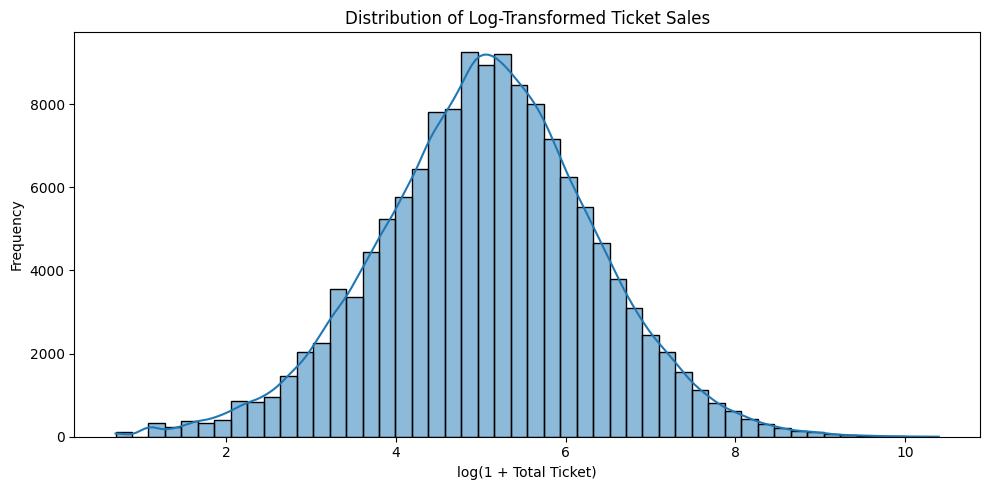

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(train["total_ticket"].clip(lower=0)),
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Ticket Sales")
plt.xlabel("log(1 + Total Ticket)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ALHAMDULILLAH PAS GRAFIKNYA

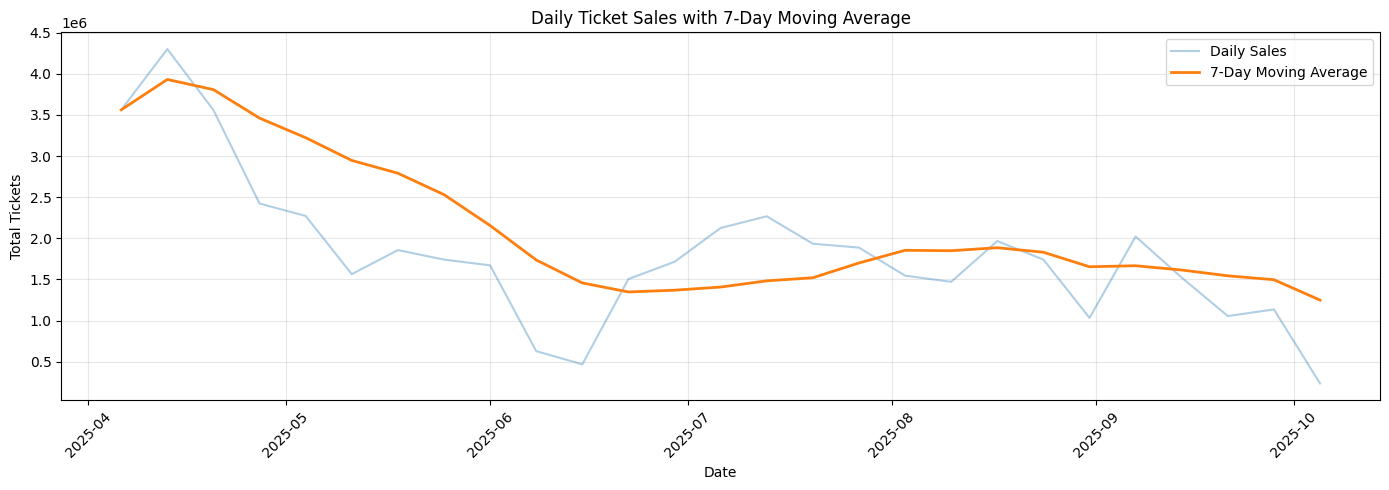

In [11]:
#AWAK BIKIN PERMINGGU
daily_sales["rolling_7d"] = (
    daily_sales["total_ticket"]
    .rolling(7, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date_show"],
    daily_sales["total_ticket"],
    alpha=0.35,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date_show"],
    daily_sales["rolling_7d"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.title("Daily Ticket Sales with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Total Tickets")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Grafiknya turun drastis ya. hmz
- oke good, ga lari banget


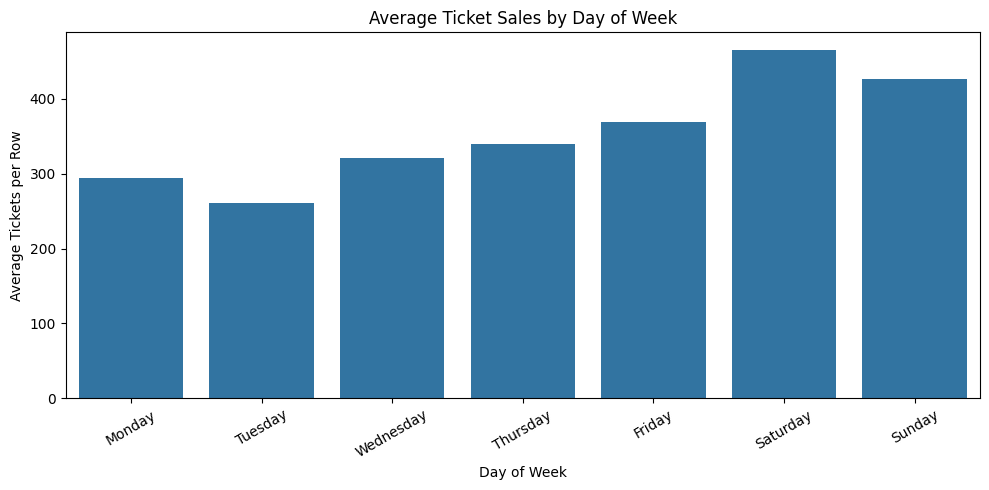

In [12]:
train["day_of_week"] = train["date_show"].dt.dayofweek

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

train["day_name"] = train["day_of_week"].map(day_names)

weekday_sales = (
    train.groupby("day_name")["total_ticket"]
    .mean()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.title("Average Ticket Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Tickets per Row")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Memang sabtu minggu itu terbaik buat nonton we, aplagi pacaran

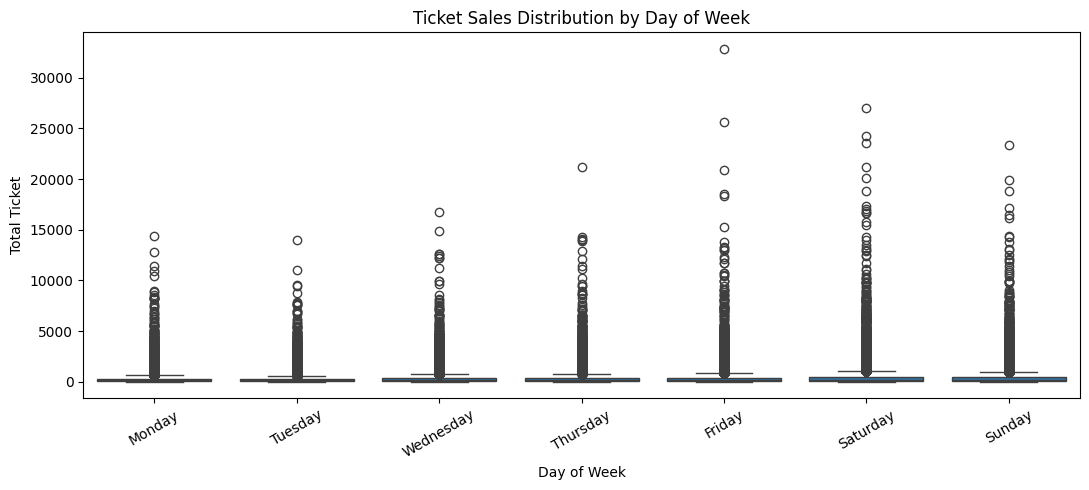

In [13]:
plt.figure(figsize=(11, 5)) #Ini kalau pakai semua datanya ya soalnya ini perbandingan ama distribusi

sns.boxplot(
    data=train,
    x="day_name",
    y="total_ticket",
    order=[
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ]
)

plt.title("Ticket Sales Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Ticket")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Karena sabtu itu mula libur org pulang ngantor nonton langsung keknya pas hari jumat

## **DIBAWAH INI BINTANGNYA**

In [15]:
# windows adalah DataFrame hasil sliding window
target_cols = [
    f"target_{i}" for i in range(4, 11)
]

windows["avg_d1_d3"] = windows[ #Window hari(1-3)
    ["d1", "d2", "d3"]
].mean(axis=1)

windows["avg_d4_d10"] = windows[ #Window Hari(4-10)
    target_cols
].mean(axis=1)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=windows,
    x="avg_d1_d3",
    y="avg_d4_d10",
    alpha=0.4
)

plt.title("Initial Sales vs Future Ticket Sales")
plt.xlabel("Average Tickets D1-D3")
plt.ylabel("Average Tickets D4-D10")

plt.tight_layout()
plt.show()

NameError: name 'windows' is not defined

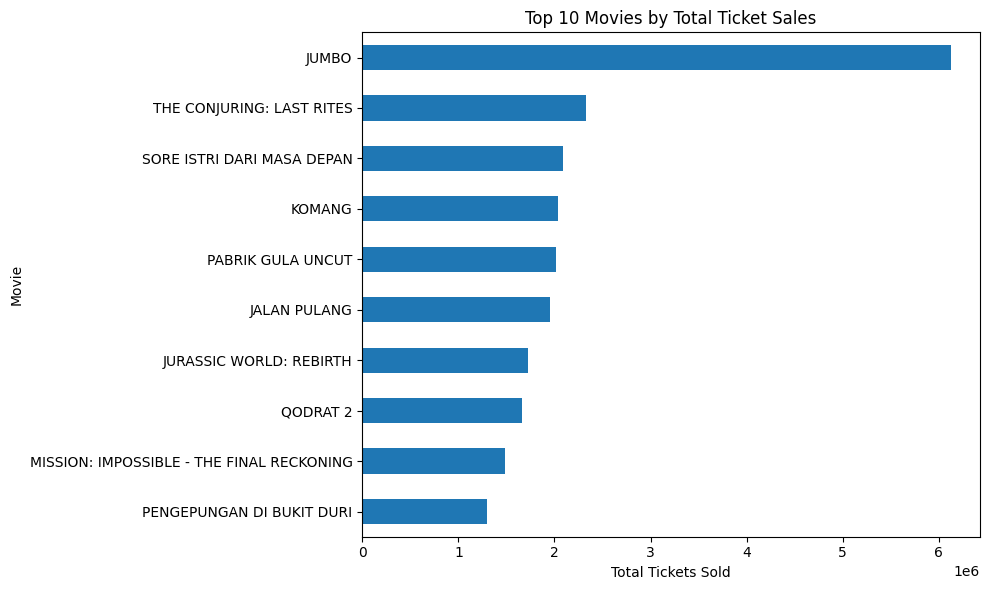

In [16]:
top_movies = (
    train.groupby("movie_title")["total_ticket"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_movies.plot(kind="barh")

plt.title("Top 10 Movies by Total Ticket Sales")
plt.xlabel("Total Tickets Sold")
plt.ylabel("Movie")

plt.tight_layout()
plt.show()

In [17]:
price_col = "ticket_price"

price_city = prices[
    ["city_name", price_col]
].drop_duplicates()

price_sales = train.merge(
    price_city,
    on="city_name",
    how="left"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=price_sales,
    x=price_col,
    y="total_ticket",
    alpha=0.4
)

plt.title("Ticket Price vs Ticket Sales")
plt.xlabel("Ticket Price")
plt.ylabel("Total Tickets")

plt.tight_layout()
plt.show()

NameError: name 'prices' is not defined

PENYELESAIAN AKHIR DIBAWAH INI
- kenapa akhir?
karena ini membandingkna hasil train X validasi kita

tabel dibawah ini tabel actual vs predict

In [18]:
sample_idx = 0

days = list(range(4, 11))

plt.figure(figsize=(9, 5))

plt.plot(
    days,
    np.array(Y_valid)[sample_idx],
    marker="o",
    label="Actual"
)

plt.plot(
    days,
    np.array(Y_pred)[sample_idx],
    marker="o",
    label="Predicted"
)

plt.title("Actual vs Predicted: D4-D10")
plt.xlabel("Forecast Day")
plt.ylabel("Total Tickets")
plt.xticks(days)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'Y_valid' is not defined

<Figure size 900x500 with 0 Axes>